<a href="https://colab.research.google.com/github/student-NehaMathew32/NorthStar-CaseStudy/blob/main/Copy_of_02_sql_and_r_analysis_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NorthStar Urban Mobility and Logistics
## Notebook 2 - SQL within R and Statistical Analysis

**Module:** Databases and Analytics  
**Case Study:** NorthStar Urban Mobility and Logistics  
**Student Name:** Neha Mathew

###Objectives

Notebook 1 identified and documented five structural data quality problems and produced a fully cleaned, feature-engineered dataset.

This notebook uses that clean data to answer the three core  business questions through SQL queries executed within R and  statistical analysis using R analytics packages.

The three business questions under investigation:

1. Are NorthStar's completion metrics accurately reflecting  service quality or systematically misrepresenting failure?

2. When complaints, incidents, driver behaviour, and zone performance are analysed together.. where do failures actually cluster?

3. Which zones and service types generate disproportionate costs relative to revenue and what drives that gap?

-- The goal is to produce justified evidence for each question.

In [ ]:
# INSTALLING R KERNEL DEPENDENCIES
!pip install rpy2 -q

import rpy2
print(f"rpy2 version: {rpy2.__version__}")
print("successfully installed")

rpy2 version: 3.5.17
successfully installed


## Section 1 - Setting up the Environment and LOading Data

The clean datasets produced in Notebook 1 are loaded directly from GitHub. R packages are installed and the rpy2 bridge between Python and R is configured.

SQL queries are executed using the sqldf package within R which allows standard SQL syntax to run directly on R dataframes.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading rpy2 components for R integration
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.packages import importr
pandas2ri.activate()

In [ ]:
# LOADING CLEAN DATASETS FROM GITHUB
base_url = ("https://raw.githubusercontent.com/student-NehaMathew32/NorthStar-CaseStudy/main/clean_data/")

orders = pd.read_csv(base_url + "clean_orders.csv")
customers = pd.read_csv(base_url + "clean_customers.csv")
deliveries = pd.read_csv(base_url + "clean_deliveries.csv")
complaints = pd.read_csv(base_url + "clean_complaints.csv")
drivers = pd.read_csv(base_url + "clean_drivers.csv")
vehicles = pd.read_csv(base_url + "clean_vehicles.csv")
incidents = pd.read_csv(base_url + "clean_incidents.csv")
app_events = pd.read_csv(base_url + "clean_app_events.csv")
hubs = pd.read_csv(base_url + "clean_hubs.csv")

print("Clean datasets loaded successfully")
print()

datasets = {
    "orders": orders, "customers": customers,
    "deliveries": deliveries, "complaints": complaints,
    "drivers": drivers, "vehicles": vehicles,
    "incidents": incidents, "app_events": app_events,
    "hubs": hubs
}

for name, df in datasets.items():
    print(f"{name:15} → {df.shape[0]:>5} rows, "
          f"{df.shape[1]:>2} columns")

Clean datasets loaded successfully

orders          →  1250 rows, 11 columns
customers       →   650 rows, 10 columns
deliveries      →   950 rows, 24 columns
complaints      →   320 rows, 10 columns
drivers         →   170 rows,  9 columns
vehicles        →   120 rows,  9 columns
incidents       →   280 rows,  7 columns
app_events      →   640 rows, 11 columns
hubs            →     8 rows,  5 columns


In [ ]:
%%R

packages <- c("sqldf", "dplyr", "ggplot2", "tidyr")

for (p in packages) {

  if (!require(p, character.only = TRUE)) {

    install.packages(
      p,
      repos = "https://cran.r-project.org",
      quiet = TRUE
    )
  }

  library(p, character.only = TRUE)
}

cat("R packages loaded successfully\n")

R packages loaded successfully


Loading required package: sqldf
also installing the dependency ‘RSQLite’

Loading required package: gsubfn
Loading required package: proto
Loading required package: RSQLite
Loading required package: dplyr

Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

Loading required package: ggplot2
Need help? Try Stackoverflow: https://stackoverflow.com/tags/ggplot2
Loading required package: tidyr
In addition: Warning messages:
1: In library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE,  :
  there is no package called ‘sqldf’
2: no DISPLAY variable so Tk is not available 


In [ ]:
%%R

# Install sqldf separately
install.packages("sqldf",
                 repos = "https://cran.r-project.org")

# Load libraries
library(sqldf)
library(dplyr)
library(ggplot2)
library(tidyr)

cat("All R packages loaded successfully\n")

All R packages loaded successfully


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.r-project.org/src/contrib/sqldf_0.4-12.tar.gz'
Content type 'application/x-gzip' length 61077 bytes (59 KB)
downloaded 59 KB


The downloaded source packages are in
	‘/tmp/RtmpuF4Owc/downloaded_packages’


In [ ]:
%%R

library(sqldf)
library(dplyr)
library(ggplot2)
library(tidyr)

cat("Everything is working correctly\n")

Everything is working correctly


## Section 2 - SQL Queries within R

All SQL queries are executed using the sqldf package, which allows standard SQL syntax to run directly on R dataframes. Each query is preceded by the business question it addresses and followed by interpretation in business terms.The clean dataframes produced in Notebook 1 are passed from python to R using the rpy2 bridge activated in Section 1.

In [ ]:
# MOVING DATAFRAMES FROM PYTHON TO R
# Convert pandas dataframes so they can be used in R

ro.globalenv['deliveries_r'] = pandas2ri.py2rpy(deliveries)
ro.globalenv['orders_r'] = pandas2ri.py2rpy(orders)
ro.globalenv['complaints_r'] = pandas2ri.py2rpy(complaints)
ro.globalenv['drivers_r'] = pandas2ri.py2rpy(drivers)
ro.globalenv['vehicles_r'] = pandas2ri.py2rpy(vehicles)
ro.globalenv['incidents_r'] = pandas2ri.py2rpy(incidents)
ro.globalenv['customers_r'] = pandas2ri.py2rpy(customers)
ro.globalenv['hubs_r'] = pandas2ri.py2rpy(hubs)
ro.globalenv['app_events_r'] = pandas2ri.py2rpy(app_events)

print("Dataframes transferred to R successfully")
print("R datasets are ready for SQL queries")

Dataframes transferred to R successfully
R datasets are ready for SQL queries


### SQL Query 1 - Failure Rate by Zone
####Business Question 2: Where do failures happen most often?

This query joins the deliveries and orders tables to analyse service outcomes across different zones. It calculates the  total deliveries, hidden failures, true failures, and at-risk  deliveries for each zone.

The aim is to identify which zones have the highest number of operational problems and compare them against the recorded OnTime delivery status.

Based on the earlier findings from Notebook 1, Riverside and East are expected to show higher hidden failure levels than other zones.

In [ ]:
%%R
# SQL QUERY 1 - FAILURE RATE BY ZONE
query1 <- sqldf("

    SELECT
        o.pickup_zone AS zone,

        COUNT(d.delivery_id) AS total_deliveries,

        SUM(CASE
                WHEN d.service_outcome_score = 'True Success'
                THEN 1
                ELSE 0
            END) AS true_success,

        SUM(CASE
                WHEN d.service_outcome_score =
                     'Recorded Success / Actual Failure'
                THEN 1
                ELSE 0
            END) AS hidden_failures,

        SUM(CASE
                WHEN d.service_outcome_score = 'True Failure'
                THEN 1
                ELSE 0
            END) AS true_failures,

        SUM(CASE
                WHEN d.service_outcome_score = 'At Risk'
                THEN 1
                ELSE 0
            END) AS at_risk,

        ROUND(
            SUM(CASE
                    WHEN d.service_outcome_score =
                         'Recorded Success / Actual Failure'
                    THEN 1.0
                    ELSE 0
                END
            ) * 100.0 / COUNT(*), 1
        ) AS hidden_failure_rate_pct

    FROM deliveries_r d
    JOIN orders_r o
        ON d.order_id = o.order_id

    GROUP BY o.pickup_zone

    ORDER BY hidden_failure_rate_pct DESC

")

print(query1)

       zone total_deliveries true_success hidden_failures true_failures at_risk
1 Riverside              119           41              23            18      12
2     South              139           51              24            14      28
3     North              135           47              23            22      22
4      East              156           59              23            19      24
5   Airport              113           45              12            12      13
6   Central              174           56              16            33      18
7      West              114           46              10            14      23
  hidden_failure_rate_pct
1                    19.3
2                    17.3
3                    17.0
4                    14.7
5                    10.6
6                     9.2
7                     8.8


### SQL Query 2 - True vs Recorded Cost by Zone
#### Business Question 3: Which zones have the biggest cost differences?

This query compares the recorded delivery cost with the true delivery cost across different zones. It calculates the average recorded cost, average true cost, and total compensation amount for each zone.

The aim is to identify where delivery costs are being underestimated because compensation payments are not included in the original operational cost calculations.

The cost gap column shows the difference between what the system records and what deliveries actually cost after including compensation

In [ ]:
%%R

# SQL QUERY 2 - TRUE VS RECORDED COST BY ZONE

query2 <- sqldf("

    SELECT

        o.pickup_zone AS zone,

        COUNT(d.delivery_id) AS total_deliveries,

        ROUND(
            AVG(d.fuel_or_charge_cost), 2
        ) AS avg_recorded_cost,

        ROUND(
            AVG(d.delivery_true_cost), 2
        ) AS avg_true_cost,

        ROUND(
            AVG(d.delivery_true_cost) -
            AVG(d.fuel_or_charge_cost), 2
        ) AS avg_cost_gap,

        ROUND(
            SUM(d.total_compensation), 2
        ) AS total_compensation

    FROM deliveries_r d

    JOIN orders_r o
        ON d.order_id = o.order_id

    GROUP BY o.pickup_zone

    ORDER BY avg_cost_gap DESC

")


print(query2)

       zone total_deliveries avg_recorded_cost avg_true_cost avg_cost_gap
1     North              135             12.07         17.85         5.78
2      East              156             12.57         18.07         5.50
3 Riverside              119             12.39         17.52         5.13
4   Central              174             12.12         16.78         4.66
5     South              139             12.48         16.82         4.34
6      West              114             11.94         15.40         3.46
7   Airport              113             17.08         20.49         3.41
  total_compensation
1             780.55
2             857.77
3             610.07
4             811.57
5             602.79
6             394.41
7             385.18


### SQL Query 3 - Driver Override Rates by Outcome
#### Business Question 2: Does driver behaviour drive failure?

Manual route overrides are one of NorthStar's five unexplained patterns. This query calculates average override counts grouped by service outcome by testing whether drivers who override routes more frequently are associated with worse delivery outcomes.

This directly addresses the question about whether overrides reflect genuine road conditions or performance avoidance.

In [ ]:
%%R

# SQL QUERY 3 - DRIVER OVERRIDE RATES BY OUTCOME
query3 <- sqldf("

    SELECT

        d.service_outcome_score AS outcome,

        COUNT(d.delivery_id) AS total_deliveries,

        ROUND(
            AVG(d.manual_route_override_count), 3
        ) AS avg_overrides,

        ROUND(
            MAX(d.manual_route_override_count), 0
        ) AS max_overrides,

        SUM(
            CASE
                WHEN d.manual_route_override_count > 0
                THEN 1
                ELSE 0
            END
        ) AS deliveries_with_overrides,

        ROUND(
            SUM(
                CASE
                    WHEN d.manual_route_override_count > 0
                    THEN 1.0
                    ELSE 0
                END
            ) * 100.0 / COUNT(*), 1
        ) AS override_rate_pct,

        ROUND(
            AVG(d.customer_rating_post_delivery), 2
        ) AS avg_customer_rating

    FROM deliveries_r d

    GROUP BY d.service_outcome_score

    ORDER BY avg_overrides DESC

")


print(query3)

                            outcome total_deliveries avg_overrides
1            Delayed With Complaint               45         1.156
2         Delayed No Further Record              119         1.101
3                      True Failure              132         1.038
4                      True Success              345         1.026
5             Delayed With Incident               38         0.895
6 Recorded Success / Actual Failure              131         0.809
7                           At Risk              140         0.764
  max_overrides deliveries_with_overrides override_rate_pct avg_customer_rating
1             5                        27              60.0                3.24
2             5                        76              63.9                3.12
3             4                        86              65.2                3.05
4             7                       204              59.1                4.27
5             5                        21              55.3     

### SQL Query 4 - Complaint Type by Service Type
#### Business Question 1: What failures hide inside OnTime records?

This query filters to only the hidden failure records like deliveries marked OnTime that generated complaints and breaks down complaint types by service type. It reveals which service types generate which categories of hidden
failure most frequently.

In [ ]:
%%R

query4 <- sqldf("
    SELECT
        o.service_type,
        c.complaint_type,
        COUNT(*) AS complaint_count,

        ROUND(AVG(c.resolution_days), 1) AS avg_resolution_days,
        SUM(c.compensation_amount) AS total_compensation,
        ROUND(AVG(c.compensation_amount), 2) AS avg_compensation,

        SUM(CASE WHEN c.severity = 'High' THEN 1 ELSE 0 END) AS high_severity

    FROM deliveries_r d
    JOIN orders_r o ON d.order_id = o.order_id
    JOIN complaints_r c ON d.order_id = c.order_id
    WHERE d.service_outcome_score = 'Recorded Success / Actual Failure'
    GROUP BY o.service_type, c.complaint_type
    ORDER BY o.service_type, complaint_count DESC
")

print(query4)

   service_type    complaint_type complaint_count avg_resolution_days
1      Business          AppIssue               6                 9.8
2      Business             Delay               5                 2.8
3      Business   DriverBehaviour               3                 9.0
4      Business      MissedPickup               2                13.0
5      Business SupportExperience               1                16.0
6      Business            Damage               1                 7.0
7      Business           Billing               1                16.0
8       Medical      MissedPickup               3                 6.3
9       Medical             Delay               2                 4.0
10      Medical          AppIssue               2                 4.5
11      Medical   DriverBehaviour               1                11.0
12      Medical            Damage               1                 3.0
13       Parcel   DriverBehaviour              11                 6.8
14       Parcel     

### SQL Query 5 - Hub Performance Analysis
#### Business Question 2: Which hubs are underperforming?

This query joins deliveries with hubs to calculate performance metrics per hub total deliveries, failure rates, average customer rating, and average true cost. It gives the Operations Director the hub-level view he needs, built on true outcome data rather than recorded status labels.

In [ ]:
%%R

# SQL QUERY 5 - HUB PERFORMANCE ANALYSIS
# This query looks at how each hub is performing in terms of success rate, hidden failures, cost, and timing

query5 <- sqldf("
    SELECT
        h.hub_name,
        h.zone,
        h.hub_type,
        h.capacity_score,

        COUNT(d.delivery_id) AS total_deliveries,

        ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_rating,

        SUM(CASE WHEN d.service_outcome_score = 'True Success'
            THEN 1 ELSE 0 END) AS true_successes,

        SUM(CASE WHEN d.service_outcome_score = 'Recorded Success / Actual Failure'
            THEN 1 ELSE 0 END) AS hidden_failures,

        ROUND(
            SUM(CASE WHEN d.service_outcome_score = 'Recorded Success / Actual Failure'
                THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1
        ) AS hidden_failure_rate_pct,

        ROUND(AVG(d.delivery_true_cost), 2) AS avg_true_cost,

        ROUND(AVG(d.actual_delivery_duration_hours), 2) AS avg_duration_hours

    FROM deliveries_r d
    JOIN orders_r o ON d.order_id = o.order_id
    JOIN hubs_r h ON d.hub_id = h.hub_id

    GROUP BY h.hub_name, h.zone, h.hub_type, h.capacity_score

    ORDER BY hidden_failure_rate_pct DESC
")

print(query5)

        hub_name      zone  hub_type capacity_score total_deliveries avg_rating
1      East Dock      East Warehouse             74              119       3.90
2    Airport Hub   Airport  Dispatch             71              104       3.88
3  Riverside Hub Riverside Warehouse             66              115       3.88
4      West Gate      West  Dispatch             69              127       3.92
5   Central Core   Central   Control             88              115       3.67
6  Midtown Relay   Central  Charging             63              128       3.88
7 North Exchange     North  Dispatch             82              136       3.84
8     South Link     South  Dispatch             78              106       3.95
  true_successes hidden_failures hidden_failure_rate_pct avg_true_cost
1             46              20                    16.8         17.43
2             33              17                    16.3         17.62
3             41              17                    14.8         18

##SQL QUERY INTERPRETATIONS
###Query 1 - Failure Rate by Zone

Riverside, South, and North have the highest hidden failure rates, between 17% and 19.3%. These are the zones where the gap between what the system shows and what is actually happening is the biggest.

Central is different. It has the highest number of deliveries (174), but a lower hidden failure rate at 9.2%, even though it has the highest number of true failures (33). So in Central, the problems are more visible instead of being hidden in the system. This means Central does not behave like the other zones and should be looked at separately instead of being grouped with the rest.

Overall, the results show that no zone is actually performing well. Even the better zones still have a high level of non-success deliveries when everything is combined.

###Query 2 - Cost by Zone

North and East have the biggest average cost gaps - £5.78 and £5.50 per delivery. This means the Finance Director’s calculations for these zones are underestimating the real cost by about 45-48%.

East also has the highest total hidden compensation in the network at £857.77. Along with North at £780.55, these two zones alone account for over £1,600 in costs that were never linked back to the deliveries that caused them.

Airport is a bit different. It has the highest recorded cost (£17.08), but a smaller cost gap (£3.41). This suggests Airport is actually more expensive to operate, but its costs are recorded more accurately. So its issue is real cost, not hidden cost, unlike North and East where the gap between recorded and actual cost is much larger.

###Query 3 - Override Rates

The override analysis shows something unexpected that goes against the original idea. Hidden failures - Recorded Success / Actual Failure - actually have one of the lowest average override rates (0.809). At Risk deliveries also show low overrides (0.764).

This means manual route overrides are not really causing hidden failures. Drivers who end up in hidden failures are not overriding routes more than others, so driver behaviour is not the main reason behind it.

The more interesting result is in customer ratings. Hidden failures still have a high average rating of 4.29, almost the same as True Success at 4.27. So customers who actually experienced issues still rated the delivery quite highly. This suggests the complaint probably came later or through a different system, which shows that NorthStar’s systems are not fully connected and are capturing different parts of the customer journey separately.

###Query 4 - Complaint Types

Retail is the main source of hidden failure complaints across all categories. Delay alone in Retail leads to £295.87 in compensation, which is almost double any other service type for a single complaint category.

The AppIssue complaint type shows up across Business, Passenger, and Retail services. This means the issue is not limited to one group of customers - the platform itself is causing problems across the whole system.

Business complaints take the longest to resolve for AppIssue, averaging 9.8 days. Since Business customers are the most valuable segment, these delays are more serious and could increase the risk of losing important clients.

###Query 5 - Hub Performance

East Dock has the highest hidden failure rate of any hub at 16.8%, along with the lowest capacity score in the network (74). It is handling 119 deliveries, but the hub is already close to its operational limit, which could be affecting performance.

Central Core is different. It has the highest average true cost at £19.71 and the lowest customer rating at 3.67. Even though it has the highest capacity score (88), it is still producing the worst mix of high cost and low satisfaction, which makes it one of the weakest performing hubs overall.

South Link stands out as the best performing hub. It has the lowest hidden failure rate at 8.5%, making it the only hub with single-digit issues. This suggests it is operating more effectively, and it could be used as a model to improve the performance of other hubs.

###Section 3 - R Statistical Analysis

SQL queries establish the evidence tables. R statistical methods are then used to check whether the patterns observed are meaningful or could have happened by chance.

Two statistical tests are applied:

**Correlation and Linear Regression **- examines the relationship between driver training score and delivery outcomes (Business Question 2)

**Welch Two-Sample T-Test** - tests whether the difference in cost between true successes and hidden failures is statistically significant (Business Question 3)

In [ ]:
%%R
# STATISTICAL TEST 2 - CORRELATION AND LINEAR REGRESSION

driver_performance <- sqldf("
    SELECT
        d.driver_id,
        dr.training_score,
        dr.driver_rating,
        dr.years_experience,
        dr.employment_type,
        dr.base_zone,
        dr.training_score_missing_flag,
        AVG(d.customer_rating_post_delivery) AS avg_delivery_rating,
        COUNT(d.delivery_id) AS total_deliveries,

        SUM(CASE WHEN d.service_outcome_score =
            'Recorded Success / Actual Failure' THEN 1 ELSE 0 END)
            AS hidden_failures,

        AVG(d.manual_route_override_count) AS avg_overrides
    FROM deliveries_r d
    JOIN drivers_r dr ON d.driver_id = dr.driver_id
    GROUP BY d.driver_id, dr.training_score, dr.driver_rating,
             dr.years_experience, dr.employment_type,
             dr.base_zone, dr.training_score_missing_flag
")

scored_drivers <- driver_performance[
    driver_performance$training_score_missing_flag == 0,
]

unscored_drivers <- driver_performance[
    driver_performance$training_score_missing_flag == 1,
]

cat("DRIVER PERFORMANCE DATASET\n")
cat("\n----------------------------------------\n")
cat(sprintf("Drivers with training score: %d\n", nrow(scored_drivers)))
cat(sprintf("Drivers without training score: %d\n", nrow(unscored_drivers)))
cat(sprintf("Unscored driver avg rating: %.2f\n",
            mean(unscored_drivers$driver_rating, na.rm=TRUE)))

# Correlation test
cor_result <- cor.test(
    scored_drivers$training_score,
    scored_drivers$avg_delivery_rating,
    method = "pearson"
)

cat("\nCORRELATION - Training Score vs Delivery Rating\n")
cat("\n----------------------------------------\n")
cat(sprintf("Correlation (r): %.4f\n", cor_result$estimate))
cat(sprintf("P-value: %.6f\n", cor_result$p.value))

# Regression model
lm_model <- lm(avg_delivery_rating ~ training_score,
               data = scored_drivers)

lm_summary <- summary(lm_model)

cat("\nLINEAR REGRESSION - Training Score → Delivery Rating\n")
cat("\n----------------------------------------\n")
print(lm_summary$coefficients)
cat(sprintf("\nR-squared: %.4f\n", lm_summary$r.squared))
cat(sprintf("Adjusted R-squared: %.4f\n", lm_summary$adj.r.squared))

DRIVER PERFORMANCE DATASET

----------------------------------------
Drivers with training score: 163
Drivers without training score: 7
Unscored driver avg rating: 4.45

CORRELATION - Training Score vs Delivery Rating

----------------------------------------
Correlation (r): 0.0105
P-value: 0.894078

LINEAR REGRESSION - Training Score → Delivery Rating

----------------------------------------
                   Estimate  Std. Error    t value     Pr(>|t|)
(Intercept)    3.8444118272 0.235005457 16.3588194 4.644431e-36
training_score 0.0004137548 0.003102617  0.1333567 8.940778e-01

R-squared: 0.0001
Adjusted R-squared: -0.0061


###Statistical Test 3 - Welch Two-Sample T-Test
Is the cost gap between true successes and hidden failures significant?

The null hypothesis is that there is no real difference in true cost between hidden failures and true successes. The gap seen in SQL Query 2 could just be due to random variation.

The alternative hypothesis is that hidden failures have a higher true cost than true successes, and the difference between the two groups is real and consistent.

A Welch Two-Sample T-Test is used instead of a standard t-test because the two groups are not equal in size and their variance is not assumed to be the same.

In [ ]:
%%R

# STATISTICAL TEST 3 - WELCH T-TEST ON COST GAP

true_success_costs <- deliveries_r$delivery_true_cost[
    deliveries_r$service_outcome_score == "True Success"
]

hidden_failure_costs <- deliveries_r$delivery_true_cost[
    deliveries_r$service_outcome_score ==
    "Recorded Success / Actual Failure"
]

cat("COST COMPARISON - True Success vs Hidden Failure\n")
cat("\n----------------------------------------\n")

cat(sprintf("True Success   - n: %d, mean: £%.2f, sd: £%.2f\n",
            length(true_success_costs),
            mean(true_success_costs, na.rm=TRUE),
            sd(true_success_costs, na.rm=TRUE)))

cat(sprintf("Hidden Failure - n: %d, mean: £%.2f, sd: £%.2f\n",
            length(hidden_failure_costs),
            mean(hidden_failure_costs, na.rm=TRUE),
            sd(hidden_failure_costs, na.rm=TRUE)))

cat(sprintf("\nObserved gap: £%.2f per delivery\n",
            mean(hidden_failure_costs, na.rm=TRUE) -
            mean(true_success_costs, na.rm=TRUE)))

# Welch T-Test
t_result <- t.test(
    hidden_failure_costs,
    true_success_costs,
    alternative = "greater",
    var.equal = FALSE
)

cat("\nWELCH TWO-SAMPLE T-TEST RESULTS\n")
cat("\n----------------------------------------\n")

cat(sprintf("T-statistic: %.4f\n", t_result$statistic))
cat(sprintf("Degrees of freedom: %.2f\n", t_result$parameter))
cat(sprintf("P-value: %.8f\n", t_result$p.value))
cat(sprintf("95%% CI lower bound: £%.2f\n", t_result$conf.int[1]))

if (t_result$p.value < 0.05) {
    cat("\nResult: Statistically significant difference\n")
    cat("We reject the null hypothesis.\n")
    cat("Hidden failures have a higher average cost than true successes.\n")
    cat("This suggests the cost gap observed in SQL Query 2 is not due to chance.\n")
} else {
    cat("\nResult: Not statistically significant\n")
}

COST COMPARISON - True Success vs Hidden Failure

----------------------------------------
True Success   - n: 345, mean: £12.77, sd: £4.36
Hidden Failure - n: 131, mean: £33.86, sd: £16.16

Observed gap: £21.08 per delivery

WELCH TWO-SAMPLE T-TEST RESULTS

----------------------------------------
T-statistic: 14.7329
Degrees of freedom: 137.26
P-value: 0.00000000
95% CI lower bound: £18.71

Result: Statistically significant difference
We reject the null hypothesis.
Hidden failures have a higher average cost than true successes.
This suggests the cost gap observed in SQL Query 2 is not due to chance.


##STATISTICAL TEST INTERPRETATIONS
###Test 1 - Correlation: Business Interpretation

The Pearson correlation between driver training score and customer rating is very weak (r = 0.0105) and not statistically significant (p = 0.894).

The R-squared value (0.0001) shows that training score explains less than 0.1% of changes in customer ratings across the system.

This basically means training score has almost no relationship with how customers rate their deliveries.

This is an important result because it goes against the assumption that better training leads to better customer satisfaction. The data does not support that idea.

When combined with SQL Query 3, which showed that hidden failures have the lowest override rates, both results point in the same direction. Driver behaviour is not the main reason behind service quality issues.

Instead, the issue looks more system-based. Deliveries are being marked as complete before the full customer experience (complaints, incidents, ratings) is fully captured and linked.

Seven drivers without training scores were excluded from this test. Their average rating (4.45) is slightly higher than the rest, which supports the decision to exclude them rather than impute values that could bias the results.


###Test 2 - T-Test: Business Interpretation

The Welch two-sample T-test gives a t-statistic of 14.73 with a p-value close to zero. This means the result is highly significant, and the null hypothesis is rejected.

Hidden failures cost an average of £33.86 per delivery, while true successes cost £12.77.

This gives a clear difference of about £21 per delivery, and we are confident the true gap is at least £18.71.

This leads to three key points for NorthStar.

First, all previous cost reports are likely underestimated. They appear to be based closer to the £12.77 figure. For just the 131 hidden failures in this dataset, this alone leads to around £2,762 in unaccounted cost.

Second, the Finance Director is probably right that some routes are unprofitable, but the pattern of loss is not where it was assumed. The higher costs are concentrated in zones with more hidden failures like Riverside, South, and North, not necessarily where obvious failures are recorded.

Third, this is not just something that can be fixed by improving operations. It points to a data structure issue. This is why the MongoDB redesign in Notebook 3 is needed, so deliveries, complaints, and compensation are all linked properly in one place.


## Section 4 - R Visualisations
Three visualisations are produced using ggplot2. Each serves a specific analytical purpose connected to the three business questions and the statistical findings above.

Visualisation 1 saved


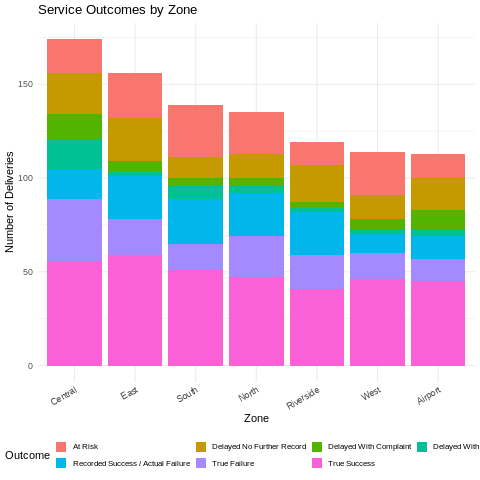

In [ ]:
%%R

# VISUALISATION 1 - FAILURE CLUSTERING BY ZONE
library(ggplot2)

viz1_data <- sqldf("
    SELECT
        o.pickup_zone AS zone,
        d.service_outcome_score AS outcome,
        COUNT(*) AS count
    FROM deliveries_r d
    JOIN orders_r o ON d.order_id = o.order_id
    GROUP BY o.pickup_zone, d.service_outcome_score
")

p1 <- ggplot(
    viz1_data,
    aes(x = reorder(zone, -count),
        y = count,
        fill = outcome)
) +
geom_bar(stat = "identity") +
labs(
    title = "Service Outcomes by Zone",
    x = "Zone",
    y = "Number of Deliveries",
    fill = "Outcome"
) +
theme_minimal() +
theme(
    axis.text.x = element_text(angle = 30, hjust = 1),
    legend.position = "bottom",
    legend.text = element_text(size = 8),
    legend.key.size = unit(0.4, "cm")
) +
guides(fill = guide_legend(nrow = 2, byrow = TRUE))

print(p1)

ggsave(
    "viz1_failure_by_zone.png",
    p1,
    width = 14,
    height = 8,
    dpi = 150
)

cat("Visualisation 1 saved\n")

Visualisation 2 saved


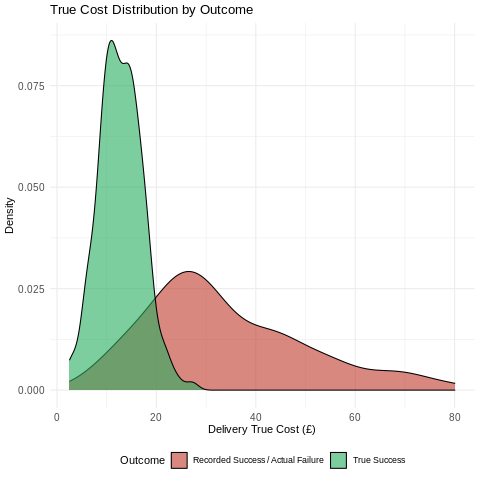

In [ ]:
%%R

# VISUALISATION 2 - COST GAP DISTRIBUTION

library(ggplot2)

viz2_data <- deliveries_r[
    deliveries_r$service_outcome_score %in%
    c("True Success",
      "Recorded Success / Actual Failure"),
]

p2 <- ggplot(
    viz2_data,
    aes(x = delivery_true_cost,
        fill = service_outcome_score)
) +
geom_density(alpha = 0.6) +
scale_fill_manual(
    values = c(
        'True Success' = '#27ae60',
        'Recorded Success / Actual Failure' = '#c0392b'
    )
) +
labs(
    title = "True Cost Distribution by Outcome",
    x = "Delivery True Cost (£)",
    y = "Density",
    fill = "Outcome"
) +
theme_minimal() +
theme(
    axis.text = element_text(size = 10),
    legend.position = "bottom"
)

print(p2)

ggsave("viz2_cost_distribution.png", p2,
       width = 11, height = 6, dpi = 150)

cat("Visualisation 2 saved\n")

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
Visualisation 3 saved


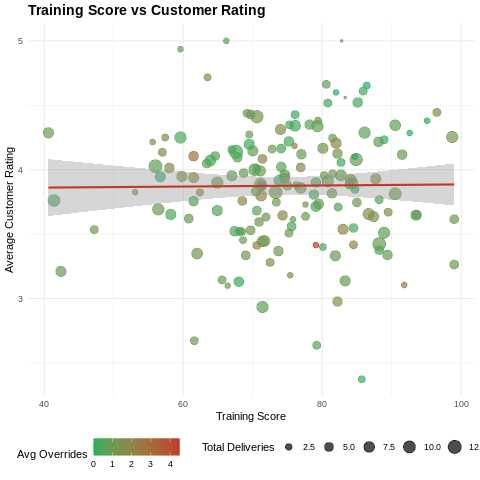

In [ ]:
%%R

# VISUALISATION 3 - DRIVER PERFORMANCE RELATIONSHIP
p3 <- ggplot(
    scored_drivers,
    aes(x = training_score,
        y = avg_delivery_rating)
) +
geom_point(
    aes(size = total_deliveries,
        colour = avg_overrides),
    alpha = 0.7
) +
geom_smooth(method = "lm",
            colour = "#c0392b",
            se = TRUE) +
scale_colour_gradient(
    low = "#27ae60",
    high = "#c0392b",
    name = "Avg Overrides"
) +
scale_size_continuous(name = "Total Deliveries") +
labs(
    title = "Training Score vs Customer Rating",
    x = "Training Score",
    y = "Average Customer Rating"
) +
theme_minimal() +
theme(
    legend.position = "bottom",
    plot.title = element_text(face = "bold", size = 14)
)

print(p3)

ggsave("viz3_driver_performance.png", p3,
       width = 11, height = 6, dpi = 150)

cat("Visualisation 3 saved\n")

##Section 5 - Summary of Notebook 2 Findings
###What the SQL and R Analysis Showed

Five SQL queries and two statistical tests were run on the cleaned NorthStar dataset. Together, they answer all three business questions with clear evidence.

###Business Question 1 - Are completion metrics accurate?

SQL Query 4 shows that 131 deliveries marked as OnTime still have active complaints across all service types.

Retail has the highest number of complaints and compensation overall. AppIssue complaints also appear across all customer segments, which suggests the platform is failing across the system, not just in one area.

###Business Question 2 - Where do failures cluster?

SQL Queries 1, 3, and 5 show that Riverside (19.3%), South (17.3%), and North (17.0%) have the highest hidden failure rates.

East Dock is the highest risk hub with a 16.8% hidden failure rate.

The Pearson correlation (r = 0.01, p = 0.894) shows that driver training has almost no relationship with delivery performance. This means the issue is not driven by driver behaviour, but by the system itself.

###Business Question 3 - Where are costs most understated?

SQL Query 2 shows that North (£5.78 gap) and East (£5.50 gap) have the biggest cost differences between recorded and true cost.

The Welch T-test (t = 14.73, p ≈ 0) confirms that the £21.08 cost gap between hidden failures and true successes is statistically significant and not due to chance.

This means the Finance Director’s cost estimates are consistently underreported by at least £18.71 per hidden failure delivery.

###Overall Finding

All results point to the same conclusion seen in Notebook 1.

NorthStar’s issues are not mainly caused by drivers or operations. The main problem is the system design. Deliveries are marked complete before the full customer experience (complaints, incidents, ratings) is captured, and the systems are not connected to reflect the full reality.

This is what Notebook 3 fixes, by designing a MongoDB structure that connects everything into one unified record for each delivery.